In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from typing import Tuple, Optional
import plotly.express as px
import plotly.graph_objects as go


In [3]:
# Get data into dataframe
df = pd.read_csv('../WMA_fractions_v2.csv', skiprows=1)

# Preprocess data to only have temperature, salinity and dissolved oxygen
df_TSO = df.copy()
df_TSO = df_TSO[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]','Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]']]
df_TSO = df_TSO.dropna()

In [4]:
def uniform_geographic_sample(
    df: pd.DataFrame,
    n_samples: int,
    lat_col: str = 'latitude',
    lon_col: str = 'longitude',
    n_grid_cells: int = 50,
    random_state: Optional[int] = None) -> pd.DataFrame:
    """
    Sample points from a dataset to minimize spatial density variability.
    
    Uses grid-based stratified sampling to ensure uniform geographic coverage.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Input dataframe with geographic coordinates
    n_samples : int
        Number of samples to draw
    lat_col : str
        Name of the latitude column
    lon_col : str
        Name of the longitude column
    n_grid_cells : int
        Number of grid cells per dimension (creates n_grid_cells x n_grid_cells grid)
    random_state : int, optional
        Random seed for reproducibility
        
    Returns:
    --------
    pd.DataFrame
        Sampled dataframe with uniform spatial distribution
    """
    if random_state is not None:
        np.random.seed(random_state)
    
    df = df.copy()
    
    # Get coordinate bounds
    lat_min, lat_max = df[lat_col].min(), df[lat_col].max()
    lon_min, lon_max = df[lon_col].min(), df[lon_col].max()
    
    # Create grid cells
    lat_bins = np.linspace(lat_min, lat_max, n_grid_cells + 1)
    lon_bins = np.linspace(lon_min, lon_max, n_grid_cells + 1)
    
    # Assign each point to a grid cell
    df['_lat_bin'] = pd.cut(df[lat_col], bins=lat_bins, labels=False, include_lowest=True)
    df['_lon_bin'] = pd.cut(df[lon_col], bins=lon_bins, labels=False, include_lowest=True)
    df['_grid_cell'] = df['_lat_bin'].astype(str) + '_' + df['_lon_bin'].astype(str)
    
    # Count points per grid cell
    cell_counts = df['_grid_cell'].value_counts()
    occupied_cells = len(cell_counts)
    
    # Calculate target samples per cell for uniform distribution
    samples_per_cell = n_samples / occupied_cells
    
    # Strategy: Sample equally from each occupied cell for uniform coverage
    # First pass: try to take equal samples from each cell
    base_samples_per_cell = n_samples // occupied_cells
    extra_samples = n_samples % occupied_cells
    
    sampled_dfs = []
    cells_to_boost = []
    
    for i, cell_id in enumerate(cell_counts.index):
        cell_df = df[df['_grid_cell'] == cell_id]
        
        # Base samples for this cell
        n_from_cell = base_samples_per_cell
        
        # Distribute extra samples to first few cells
        if i < extra_samples:
            n_from_cell += 1
        
        # Can't sample more than available in cell
        n_from_cell = min(n_from_cell, len(cell_df))
        
        if n_from_cell > 0:
            sampled = cell_df.sample(n=n_from_cell, replace=False)
            sampled_dfs.append(sampled)
        
        # Track if this cell couldn't provide enough samples
        if n_from_cell < base_samples_per_cell + (1 if i < extra_samples else 0):
            deficit = (base_samples_per_cell + (1 if i < extra_samples else 0)) - n_from_cell
            cells_to_boost.append(deficit)
    
    # Combine all samples
    result = pd.concat(sampled_dfs, ignore_index=True)
    
    # If we have a deficit, sample more from cells that have remaining points
    if len(result) < n_samples:
        remaining_df = df[~df.index.isin(result.index)]
        if len(remaining_df) > 0:
            additional_needed = n_samples - len(result)
            additional = remaining_df.sample(n=min(additional_needed, len(remaining_df)), replace=False)
            result = pd.concat([result, additional], ignore_index=True)
    
    # Remove helper columns
    result = result.drop(columns=['_lat_bin', '_lon_bin', '_grid_cell'])
    
    return result

In [5]:
df_sampled = uniform_geographic_sample(df_TSO, n_samples=100000, lat_col='Latitude_[deg_N]', lon_col='Longitude_[deg_E]', n_grid_cells=100, random_state=22)


Caching the list of root modules, please wait!
(This will only be done once - type '%rehashx' to reset cache!)


Caching the list of root modules, please wait!
(This will only be done once - type '%rehashx' to reset cache!)


Caching the list of root modules, please wait!
(This will only be done once - type '%rehashx' to reset cache!)



In [6]:
# Extract values into a tensor
X = torch.tensor(df_sampled.values, dtype=torch.float32)
dataset = TensorDataset(X)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

In [7]:
# Define Variational Autoencoder

class VAE(nn.Module):
    def __init__(self, input_dim=3, latent_dim=2):
        super().__init__()

        # Encoder
        self.fc1 = nn.Linear(input_dim, 16)
        self.fc_mu = nn.Linear(16, latent_dim)
        self.fc_logvar = nn.Linear(16, latent_dim)

        # Decoder
        self.fc2 = nn.Linear(latent_dim, 16)
        self.fc3 = nn.Linear(16, input_dim)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.fc2(z))
        return self.fc3(h)     # no sigmoid for real-valued data

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

In [8]:
# Define loss function (mse and KL divergence)
def vae_loss(recon_x, x, mu, logvar):
    mse = F.mse_loss(recon_x, x, reduction='sum')
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return mse + kld

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"

n_models = 5
reps = []

while len(reps) < n_models:

    model_idx = len(reps)
    print(f"\nTraining model {model_idx+1}/{n_models}")

    # Loop until one successful training run completes
    successful = False

    while not successful:

        # Create a fresh model + optimizer
        model = VAE(input_dim=6, latent_dim=2).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

        epochs = 50
        nan_found = False

        for epoch in range(epochs):
            model.train()
            total_loss = 0.0

            for batch in loader:
                x = batch[0].to(device)

                optimizer.zero_grad()

                recon, mu, logvar = model(x)
                loss = vae_loss(recon, x, mu, logvar)

                # Detect NaN inside the loss tensor
                if torch.isnan(loss):
                    nan_found = True
                    print(f"[Epoch {epoch}] Loss is NaN → restarting model.")
                    break

                loss.backward()
                optimizer.step()

                total_loss += loss.item()

            if nan_found:
                break  # break out of epoch loop → restart new model

            # Detect NaN in aggregated loss
            if math.isnan(total_loss):
                nan_found = True
                print(f"[Epoch {epoch}] Total loss is NaN → restarting model.")
                break

        # Check if this model finished without NaN
        if not nan_found:
            successful = True
            print("Model trained successfully (no NaNs).")

    # Extract representation after a successful training
    model.eval()
    with torch.no_grad():
        mu, logvar = model.encode(X.to(device))
        z = mu.cpu()

    reps.append(z)


Training model 1/5
Model trained successfully (no NaNs).

Training model 2/5
[Epoch 0] Loss is NaN → restarting model.
Model trained successfully (no NaNs).

Training model 3/5
[Epoch 0] Loss is NaN → restarting model.
Model trained successfully (no NaNs).

Training model 4/5
[Epoch 0] Loss is NaN → restarting model.
[Epoch 0] Loss is NaN → restarting model.
[Epoch 0] Loss is NaN → restarting model.
[Epoch 0] Loss is NaN → restarting model.
Model trained successfully (no NaNs).

Training model 5/5
Model trained successfully (no NaNs).


In [12]:
reps[2]

tensor([[ 0.0289,  4.3617],
        [ 0.0337,  4.3261],
        [12.3311,  4.5457],
        ...,
        [ 5.8713,  4.9247],
        [ 9.3214, 13.2377],
        [ 1.2249,  5.1247]])

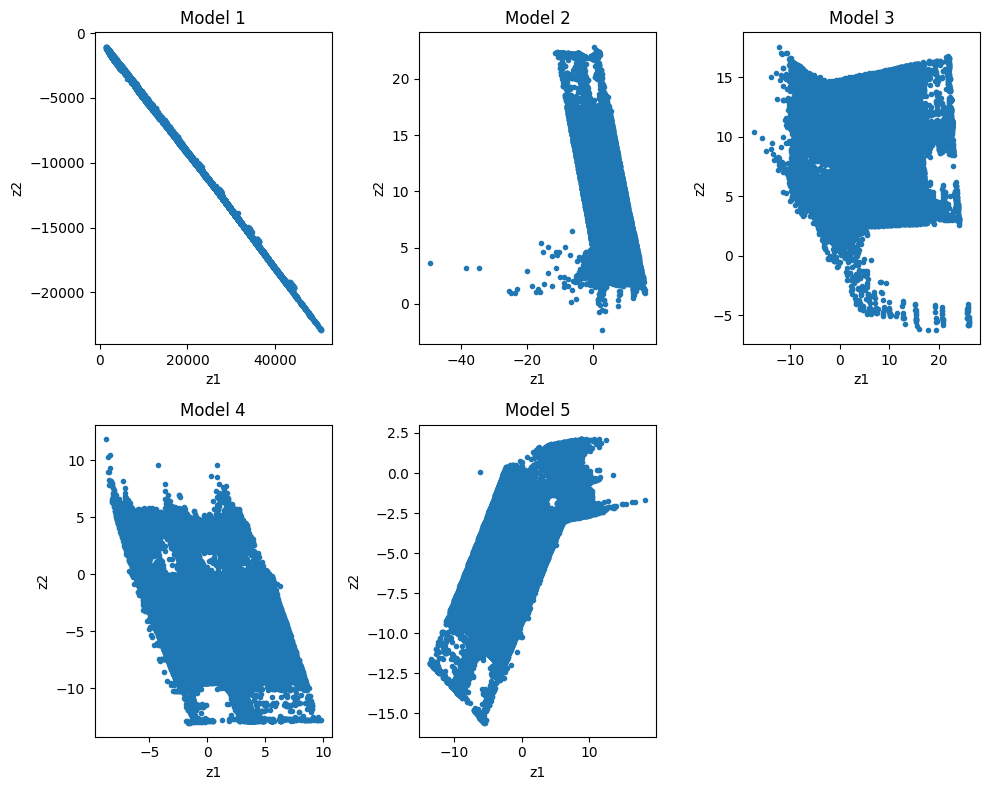

In [13]:
# Show all models' representations in one plot
fig = plt.figure(figsize=(10, 8))
for i, rep in enumerate(reps):
    ax = fig.add_subplot(2, 3, i+1)
    ax.scatter(rep[:,0].cpu().tolist(), rep[:,1].cpu().tolist(), marker='.')
    ax.set_title(f'Model {i+1}')
    ax.set_xlabel('z1')
    ax.set_ylabel('z2')

plt.tight_layout()
plt.show()

In [14]:
# Use elbow method to find optimal number of clusters for each model
from sklearn.mixture import GaussianMixture 

# Do BIC and AIC calculation for different number of clusters
bic_scores = []
aic_scores = []
ll_scores = []
n_components_range = range(1, 12)
for n_components in n_components_range:
    gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=22)
    gmm.fit(z.cpu().numpy())
    bic_scores.append(gmm.bic(z.cpu().numpy()))
    aic_scores.append(gmm.aic(z.cpu().numpy()))
    ll_scores.append(gmm.score(z.cpu().numpy()))

/Users/franciscagomes/PhD/WM_class/.venv/lib/python3.12/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Evaluating GMM metrics for model 1/5...
Evaluating GMM metrics for model 2/5...
Evaluating GMM metrics for model 3/5...
Evaluating GMM metrics for model 4/5...
Evaluating GMM metrics for model 5/5...


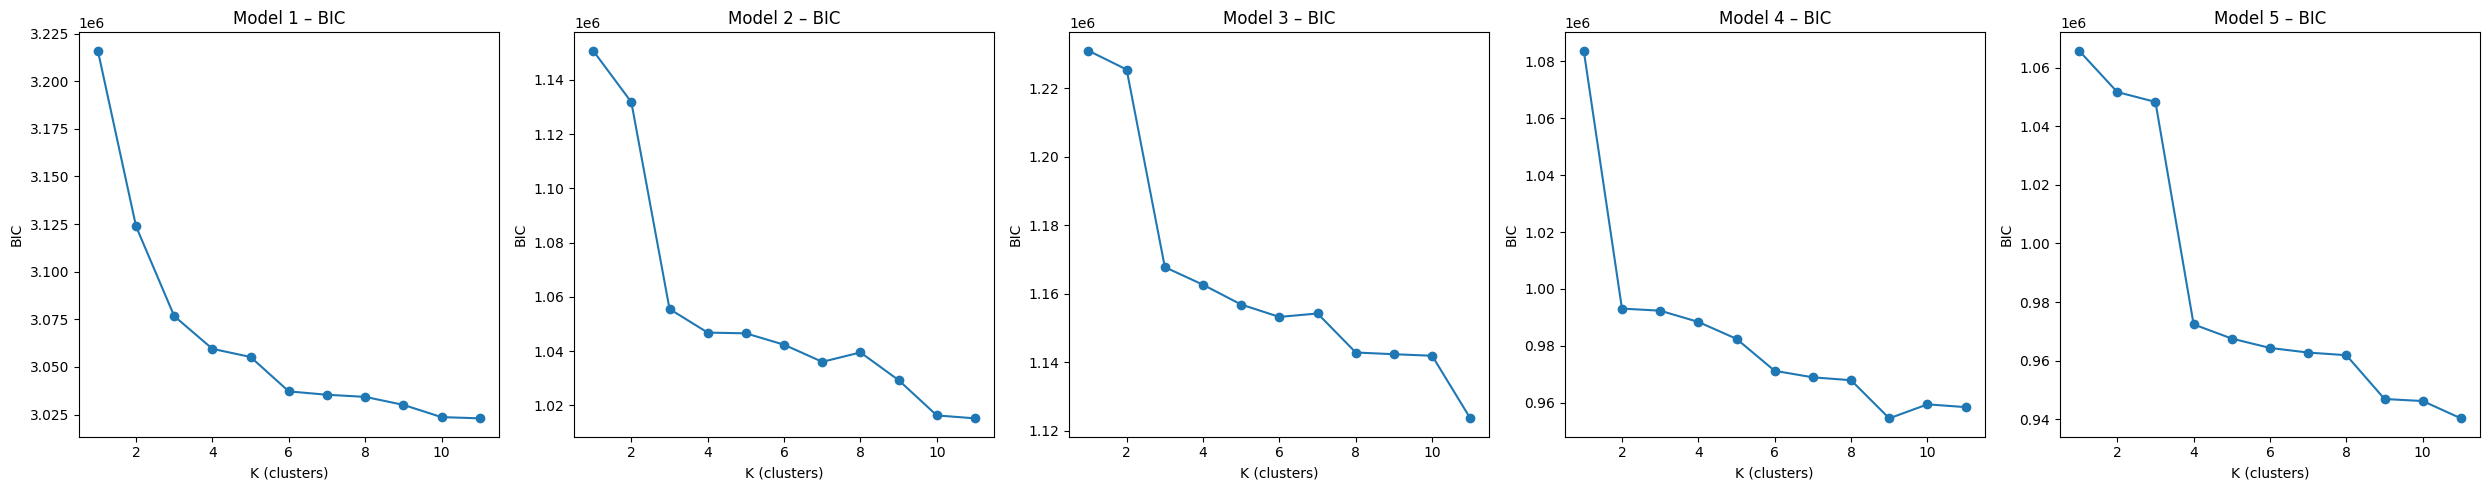

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

# reps is a list of latent matrices, one per model (shape: [N, latent_dim])
n_models = len(reps)
n_components_range = range(1, 12)

# Store scores for all models
all_bic = []

for model_idx, z in enumerate(reps):
    print(f"Evaluating GMM metrics for model {model_idx+1}/{n_models}...")

    z_np = z.cpu().numpy()

    bic_scores = []

    for n_components in n_components_range:
        gmm = GaussianMixture(
            n_components=n_components,
            covariance_type='full',
            random_state=22
        )
        gmm.fit(z_np)
        
        # BIC always defined
        bic_scores.append(gmm.bic(z_np))

    all_bic.append(bic_scores)

# Convert to numpy arrays
all_bic = np.array(all_bic)

# ───────────────────────────────────────────────
#                 PLOTTING
# ───────────────────────────────────────────────
fig, axes = plt.subplots(1, n_models, figsize=(5*n_models, 5))

for i in range(n_models):
    ax_bic = axes[i]
    ax_bic.plot(n_components_range, all_bic[i], marker='o')
    ax_bic.set_title(f"Model {i+1} – BIC")
    ax_bic.set_xlabel("K (clusters)")
    ax_bic.set_ylabel("BIC")

plt.tight_layout()
plt.show()

Evaluating GMM metrics for model 1/5...
Evaluating GMM metrics for model 2/5...
Evaluating GMM metrics for model 3/5...
Evaluating GMM metrics for model 4/5...
Evaluating GMM metrics for model 5/5...


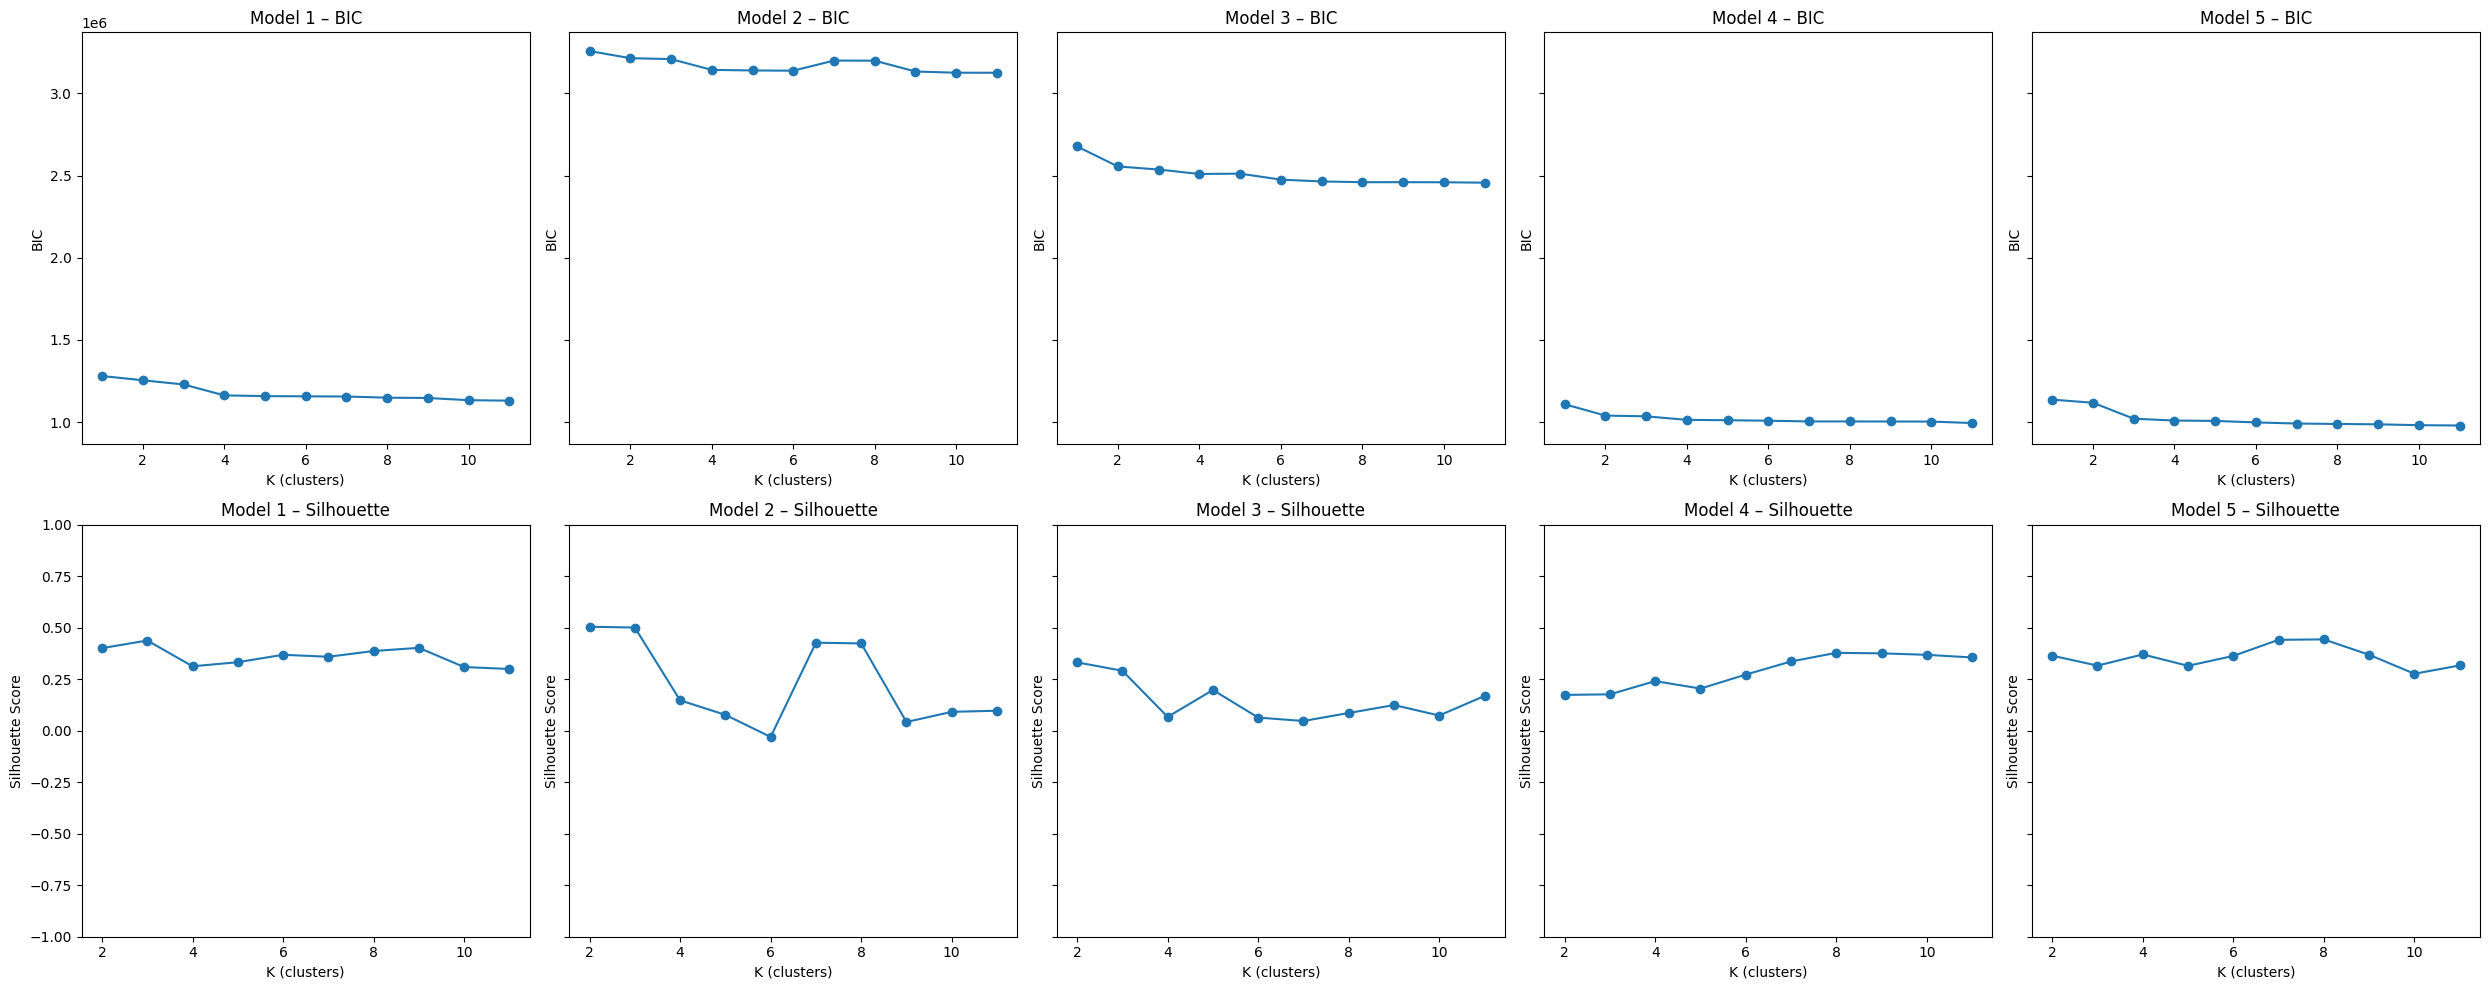

In [66]:
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.mixture import GaussianMixture
# from sklearn.metrics import silhouette_score

# # reps is a list of latent matrices, one per model (shape: [N, latent_dim])
# n_models = len(reps)
# n_components_range = range(1, 12)

# # Store scores for all models
# all_bic = []
# all_silhouette = []

# for model_idx, z in enumerate(reps):
#     print(f"Evaluating GMM metrics for model {model_idx+1}/{n_models}...")

#     z_np = z.cpu().numpy()

#     bic_scores = []
#     silhouette_scores = []

#     for n_components in n_components_range:
#         gmm = GaussianMixture(
#             n_components=n_components,
#             covariance_type='full',
#             random_state=22
#         )
#         gmm.fit(z_np)
        
#         # BIC always defined
#         bic_scores.append(gmm.bic(z_np))

#         # Silhouette only valid if n_components > 1
#         if n_components > 1:
#             labels = gmm.predict(z_np)
#             sil = silhouette_score(z_np, labels)
#             silhouette_scores.append(sil)
#         else:
#             silhouette_scores.append(np.nan)

#     all_bic.append(bic_scores)
#     all_silhouette.append(silhouette_scores)

# # Convert to numpy arrays
# all_bic = np.array(all_bic)
# all_silhouette = np.array(all_silhouette)

# # ───────────────────────────────────────────────
# #                 PLOTTING
# # ───────────────────────────────────────────────
# fig, axes = plt.subplots(2, n_models, figsize=(5*n_models, 10))

# if n_models == 1:
#     axes = np.array([[axes[0]], [axes[1]]])

# for i in range(n_models):

#     # --- Top Row: BIC ---
#     ax_bic = axes[0, i]
#     ax_bic.plot(n_components_range, all_bic[i], marker='o')
#     ax_bic.set_title(f"Model {i+1} – BIC")
#     ax_bic.set_xlabel("K (clusters)")
#     ax_bic.set_ylabel("BIC")

#     # --- Bottom Row: Silhouette ---
#     ax_sil = axes[1, i]
#     ax_sil.plot(n_components_range, all_silhouette[i], marker='o')
#     ax_sil.set_title(f"Model {i+1} – Silhouette")
#     ax_sil.set_xlabel("K (clusters)")
#     ax_sil.set_ylabel("Silhouette Score")
#     ax_sil.set_ylim(-1, 1)

# plt.tight_layout()
# plt.show()

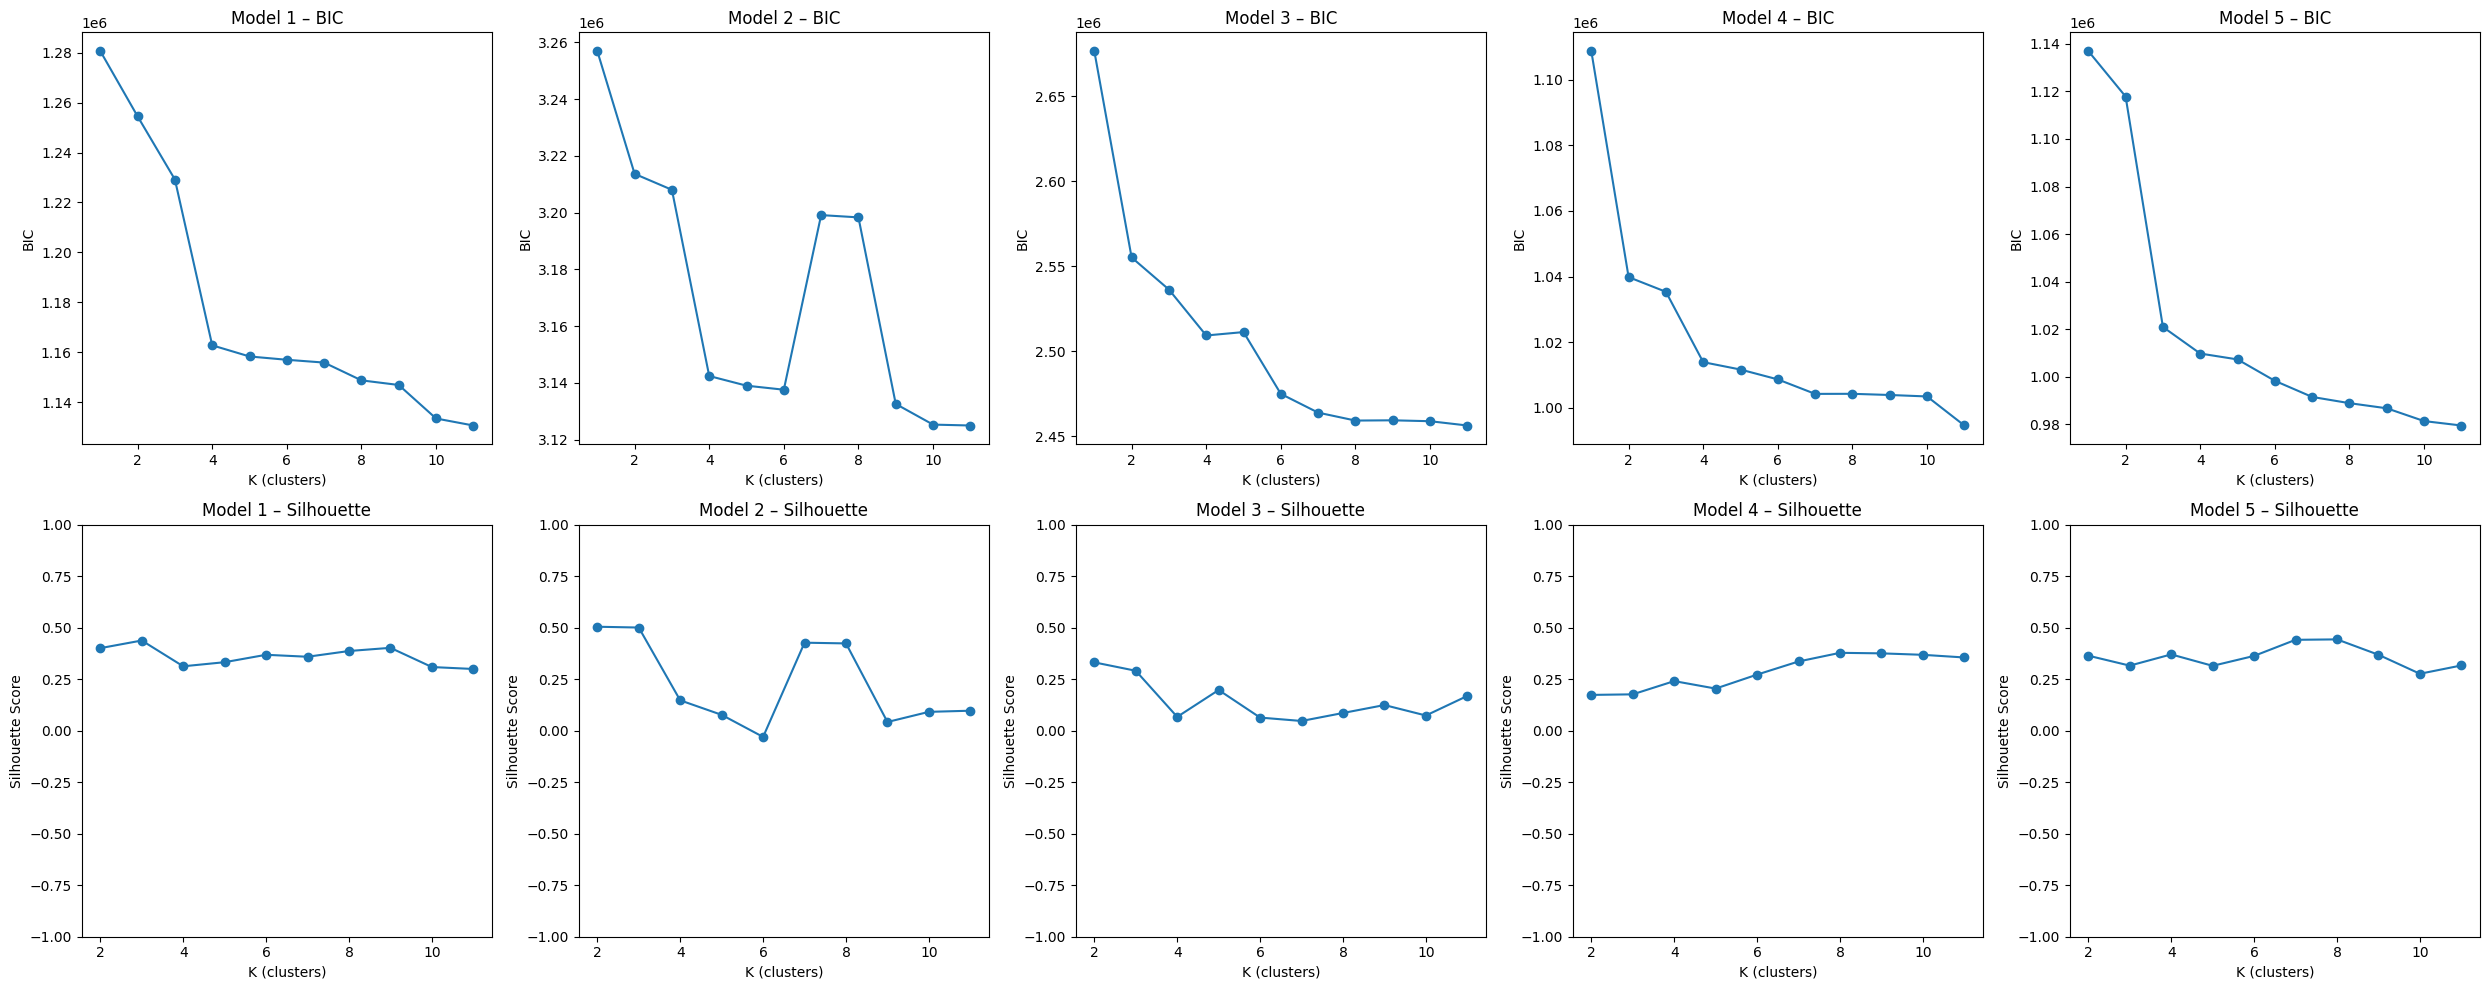

In [67]:
fig, axes = plt.subplots(2, n_models, figsize=(5*n_models, 10))

if n_models == 1:
    axes = np.array([[axes[0]], [axes[1]]])

for i in range(n_models):

    # --- Top Row: BIC ---
    ax_bic = axes[0, i]
    ax_bic.plot(n_components_range, all_bic[i], marker='o')
    ax_bic.set_title(f"Model {i+1} – BIC")
    ax_bic.set_xlabel("K (clusters)")
    ax_bic.set_ylabel("BIC")

    # --- Bottom Row: Silhouette ---
    ax_sil = axes[1, i]
    ax_sil.plot(n_components_range, all_silhouette[i], marker='o')
    ax_sil.set_title(f"Model {i+1} – Silhouette")
    ax_sil.set_xlabel("K (clusters)")
    ax_sil.set_ylabel("Silhouette Score")
    ax_sil.set_ylim(-1, 1)

plt.tight_layout()
plt.show()